In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import json
from collections import Counter
from torchvision.ops import masks_to_boxes
import torch
import matplotlib.patches as patches
from skimage.measure import label, regionprops
from datetime import datetime
from roboflow import Roboflow
from tqdm import tqdm
from PIL import Image

ModuleNotFoundError: No module named 'roboflow'

## Flower classification dataset:

In [ ]:
base = "flower_classification/progetto-finale-flowes"
splits = ["train", "valid", "test"]
classes = ["daisy", "dandelion"]

for split in splits:
    split_total = 0
    print(f"\n--- {split} ---")
    for cls in classes:
        folder = os.path.join(base, split, cls)
        all_files = os.listdir(folder)
        real_files = [f for f in all_files if not f.startswith("._")]
        count = len(real_files)
        split_total += count
        print(f"  {cls}: {count} images")
    print(f"  Total: {split_total} images")

print(f"\n--- Overall ---")
grand_total = 0
for cls in classes:
    cls_total = sum(
        len([f for f in os.listdir(os.path.join(base, s, cls)) if not f.startswith("._")])
        for s in splits
    )
    grand_total += cls_total
    print(f"  {cls}: {cls_total} images total")
print(f"  Grand total: {grand_total} images")


--- train ---
  daisy: 529 images
  dandelion: 746 images
  Total: 1275 images

--- valid ---
  daisy: 163 images
  dandelion: 201 images
  Total: 364 images

--- test ---
  daisy: 77 images
  dandelion: 105 images
  Total: 182 images

--- Overall ---
  daisy: 769 images total
  dandelion: 1052 images total
  Grand total: 1821 images


## Generate detection annotations for the classification dataset

Use the Roboflow `flower-detection-fscsr/2` model to detect flowers in each image.
The class label (daisy/dandelion) comes from the folder name, not the detector.

In [ ]:
rf = Roboflow(api_key="ROBOFLOW_API_KEY")
project = rf.workspace().project("flower-detection-fscsr")
model = project.version(2).model

In [ ]:
cls_base = "flower_classification/progetto-finale-flowes"
splits = ["train", "valid", "test"]
classes = {"daisy": 0, "dandelion": 1}

categories = [
    {"id": 0, "name": "daisy", "supercategory": "flower"},
    {"id": 1, "name": "dandelion", "supercategory": "flower"},
]

for split in splits:
    coco = {
        "info": {
            "year": "2026",
            "version": "1.0",
            "description": f"Flower classification dataset with detection boxes ({split} split)",
            "contributor": "",
            "url": "",
            "date_created": datetime.now().isoformat(),
        },
        "licenses": [{"id": 1, "url": "", "name": "Unknown"}],
        "categories": categories,
        "images": [],
        "annotations": [],
    }

    img_id = 0
    ann_id = 0

    for cls_name, cls_id in classes.items():
        folder = os.path.join(cls_base, split, cls_name)
        files = sorted([f for f in os.listdir(folder) if not f.startswith("._") and f.lower().endswith((".jpg", ".jpeg", ".png"))])

        for fname in tqdm(files, desc=f"{split}/{cls_name}"):
            img_path = os.path.join(folder, fname)
            img = Image.open(img_path)
            w, h = img.size

            coco["images"].append({
                "id": img_id,
                "file_name": f"{cls_name}/{fname}",
                "height": h,
                "width": w,
            })

            try:
                result = model.predict(img_path, confidence=30).json()
                predictions = result.get("predictions", [])
            except Exception as e:
                print(f"  Error on {fname}: {e}")
                predictions = []

            for pred in predictions:
                bx = pred["x"] - pred["width"] / 2
                by = pred["y"] - pred["height"] / 2
                bw = pred["width"]
                bh = pred["height"]

                coco["annotations"].append({
                    "id": ann_id,
                    "image_id": img_id,
                    "category_id": cls_id,
                    "bbox": [int(bx), int(by), int(bw), int(bh)],
                    "area": int(bw * bh),
                    "iscrowd": 0,
                    "segmentation": [],
                })
                ann_id += 1

            img_id += 1

    out_path = os.path.join(cls_base, split, "_annotations.coco.json")
    with open(out_path, "w") as f:
        json.dump(coco, f)

    print(f"\n{split}: {img_id} images, {ann_id} annotations -> {out_path}")

## Flower segmentation dataset:

Flower images:          8189
Segmentation masks:     8189

Total labels:           8189
Number of classes:      102 (classes 1 to 102)


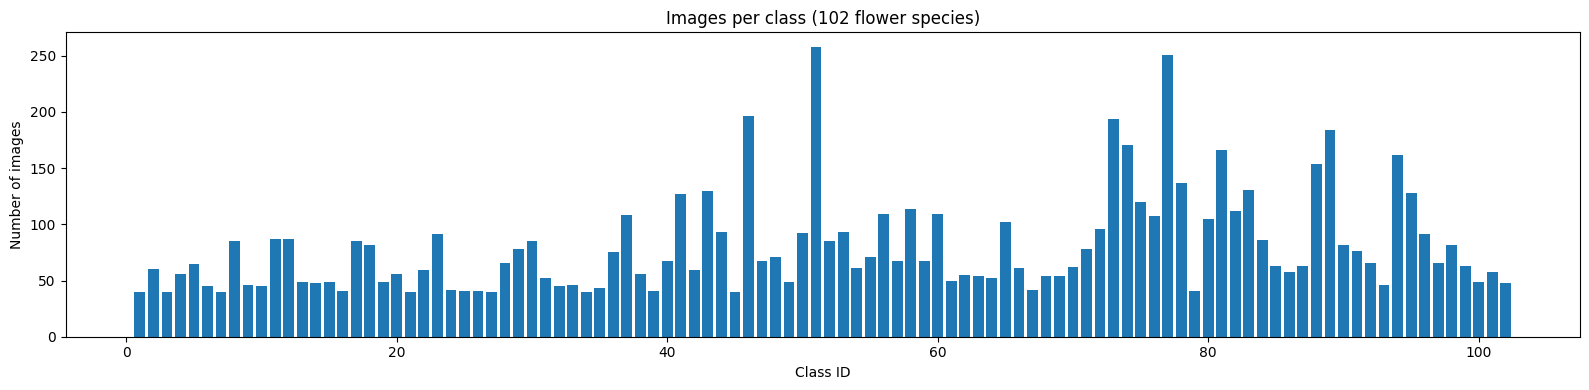


Smallest class:  class 1 with 40 images
Largest class:   class 51 with 258 images
Mean per class:  80.3 images

--- setid.mat (predefined splits) ---
  Train:      1020 images (indices 28-8177)
  Validation: 1020 images (indices 17-8187)
  Test:       6149 images (indices 1-8189)
  Total:      8189 images
  No overlap between splits ✓


In [ ]:
seg_base = "flower_segmentation"

# --- Count images and segmentation masks ---
jpg_files = [f for f in os.listdir(f"{seg_base}/jpg")]
seg_files = [f for f in os.listdir(f"{seg_base}/segmim")]

print(f"Flower images:          {len(jpg_files)}")
print(f"Segmentation masks:     {len(seg_files)}")

# --- Analyze imagelabels.mat ---
labels_mat = scipy.io.loadmat(f"{seg_base}/imagelabels.mat")
labels = labels_mat["labels"].flatten()

print(f"\nTotal labels:           {len(labels)}")
print(f"Number of classes:      {len(np.unique(labels))} (classes {labels.min()} to {labels.max()})")

vals, counts = np.unique(labels, return_counts=True)

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(vals, counts)
ax.set_xlabel("Class ID")
ax.set_ylabel("Number of images")
ax.set_title(f"Images per class ({len(vals)} flower species)")
plt.tight_layout()
plt.show()

print(f"\nSmallest class:  class {vals[counts.argmin()]} with {counts.min()} images")
print(f"Largest class:   class {vals[counts.argmax()]} with {counts.max()} images")
print(f"Mean per class:  {counts.mean():.1f} images")

# --- Analyze setid.mat ---
setid = scipy.io.loadmat(f"{seg_base}/setid.mat")

trnid = setid["trnid"].flatten()
valid = setid["valid"].flatten()
tstid = setid["tstid"].flatten()

print(f"\n--- setid.mat (predefined splits) ---")
print(f"  Train:      {len(trnid)} images (indices {trnid.min()}-{trnid.max()})")
print(f"  Validation: {len(valid)} images (indices {valid.min()}-{valid.max()})")
print(f"  Test:       {len(tstid)} images (indices {tstid.min()}-{tstid.max()})")
print(f"  Total:      {len(trnid) + len(valid) + len(tstid)} images")

# Verify no overlap
assert len(set(trnid) & set(valid)) == 0, "Train/Valid overlap!"
assert len(set(trnid) & set(tstid)) == 0, "Train/Test overlap!"
assert len(set(valid) & set(tstid)) == 0, "Valid/Test overlap!"
print("  No overlap between splits ✓")

In [65]:
labels_mat = scipy.io.loadmat(f"{seg_base}/imagelabels.mat")
all_labels = labels_mat["labels"].flatten()

unique_labels = sorted(set(all_labels))
categories = [{"id": int(cls), "name": f"flower_{cls}", "supercategory": "flower"} for cls in unique_labels]

coco_output = {
    "info": {
        "year": "2026",
        "version": "1.0",
        "description": "Flower segmentation dataset converted to COCO detection format",
        "contributor": "",
        "url": "",
        "date_created": datetime.now().isoformat(),
    },
    "licenses": [{"id": 1, "url": "", "name": "Unknown"}],
    "categories": categories,
    "images": [],
    "annotations": [],
}

jpg_files = [f for f in os.listdir(f"{seg_base}/jpg")]
seg_files = [f for f in os.listdir(f"{seg_base}/segmim")]

ann_id = 0
skipped = 0

for img_id, (image_name, seg_name) in enumerate(zip(jpg_files, seg_files)):
    image = cv2.imread(f"{seg_base}/jpg/{image_name}")
    seg = cv2.imread(f"{seg_base}/segmim/{seg_name}")

    if image is None or seg is None:
        skipped += 1
        continue

    h, w = image.shape[:2]

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    seg_rgb = cv2.cvtColor(seg, cv2.COLOR_BGR2RGB)

    difference = np.abs(image_rgb.astype(np.int16) - seg_rgb.astype(np.int16))
    foreground_mask = ~np.any(difference > 30, axis=-1)
    labeled_mask = label(foreground_mask)
    props = regionprops(labeled_mask)

    # image index is 1-based in the dataset (image_00001.jpg -> label index 0)
    label_idx = img_id
    category_id = int(all_labels[label_idx]) if label_idx < len(all_labels) else 1

    coco_output["images"].append({
        "id": img_id,
        "file_name": image_name,
        "height": h,
        "width": w,
    })

    for prop in props:
        if prop.area < 500:
            continue
        ymin, xmin, ymax, xmax = prop.bbox
        bbox_w = xmax - xmin
        bbox_h = ymax - ymin

        coco_output["annotations"].append({
            "id": ann_id,
            "image_id": img_id,
            "category_id": category_id,
            "bbox": [int(xmin), int(ymin), int(bbox_w), int(bbox_h)],
            "area": int(bbox_w * bbox_h),
            "iscrowd": 0,
            "segmentation": [],
        })
        ann_id += 1

out_path = f"{seg_base}/_annotations.coco.json"
with open(out_path, "w") as f:
    json.dump(coco_output, f)

print(f"Saved to {out_path}")
print(f"Images:      {len(coco_output['images'])}")
print(f"Annotations: {len(coco_output['annotations'])} bounding boxes")
print(f"Categories:  {len(coco_output['categories'])}")
print(f"Skipped:     {skipped} (unreadable files)")

Saved to flower_segmentation/_annotations.coco.json
Images:      8189
Annotations: 14858 bounding boxes
Categories:  102
Skipped:     0 (unreadable files)


## Flower detection dataset:

- The dataset includes 3336 images.
- Flower are annotated in COCO format.

Images:      3336
Annotations: 4852 bounding boxes
Categories:  14

Class                  ID    Boxes
-----------------------------------
flower                  0        0
0                       1      533
ANGGREK                 2      185
ASTER                   3      197
Aglonema                4      212
Bunga Coleus            5      255
Holiday Cactus          6       12
Kenanga                 7      650
Kupu-Kupu               8      745
Melati                  9      962
ROSE-MAWAR             10       99
Rose-Mawar             11      567
SUN FLOWER             12      224
TULIP                  13      211


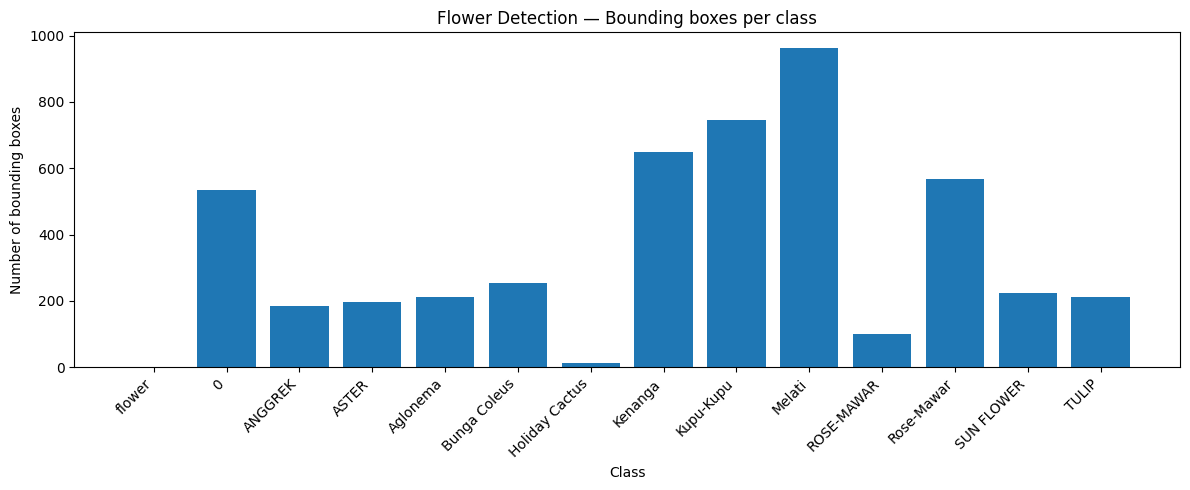


Potential issues:
  - 'flower' (id=0) has 0 annotations — generic/unused category?
  - Duplicate rose classes: ['ROSE-MAWAR', 'Rose-Mawar'] with [99, 567] boxes — consider merging


In [ ]:
det_base = "flower_detection/train"

with open(f"{det_base}/_annotations.coco.json", "r") as f:
    coco = json.load(f)

cat_map = {c["id"]: c["name"] for c in coco["categories"]}
cat_counts = Counter(a["category_id"] for a in coco["annotations"])

print(f"Images:      {len(coco['images'])}")
print(f"Annotations: {len(coco['annotations'])} bounding boxes")
print(f"Categories:  {len(coco['categories'])}")

print(f"\n{'Class':<20} {'ID':>4} {'Boxes':>8}")
print("-" * 35)
for cat in coco["categories"]:
    count = cat_counts.get(cat["id"], 0)
    print(f"{cat['name']:<20} {cat['id']:>4} {count:>8}")

# Bar chart
names = [cat["name"] for cat in coco["categories"]]
counts = [cat_counts.get(cat["id"], 0) for cat in coco["categories"]]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, counts)
ax.set_xlabel("Class")
ax.set_ylabel("Number of bounding boxes")
ax.set_title("Flower Detection — Bounding boxes per class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Flag potential issues
print("\nPotential issues:")
if cat_counts.get(0, 0) == 0 and "flower" in cat_map.values():
    print("  - 'flower' (id=0) has 0 annotations — generic/unused category?")
rose_ids = [c["id"] for c in coco["categories"] if "rose" in c["name"].lower() or "mawar" in c["name"].lower()]
if len(rose_ids) > 1:
    rose_names = [cat_map[i] for i in rose_ids]
    rose_counts = [cat_counts.get(i, 0) for i in rose_ids]
    print(f"  - Duplicate rose classes: {rose_names} with {rose_counts} boxes — consider merging")